# 데이터 불러오기

In [239]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [240]:
dataset = pd.read_csv("Google_Stock.csv")
dataset.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
1,2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2,2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
3,2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
4,2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512


In [241]:
x = dataset.index.to_frame()
y = dataset[["Close"]]

x.head(), len(x), y.head(), len(y)

(   0
 0  0
 1  1
 2  2
 3  3
 4  4,
 4858,
       Close
 0  2.499133
 1  2.697639
 2  2.724787
 3  2.611960
 4  2.640104,
 4858)

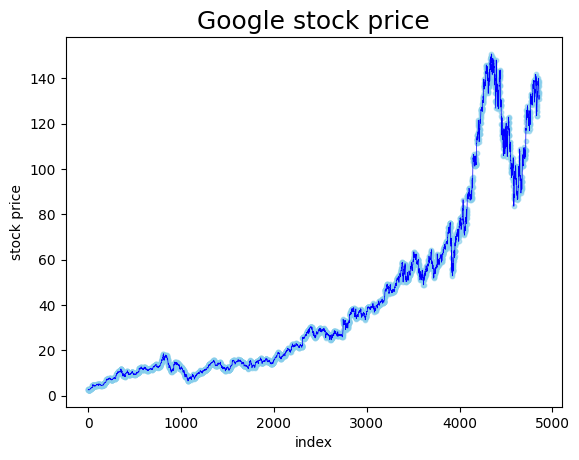

In [242]:
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5)
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.xlabel("index")
plt.ylabel("stock price")
plt.title("Google stock price", fontsize=18)
plt.show()

## Train test Split

In [243]:
from sklearn.model_selection import train_test_split

In [244]:
x_train, x_test, y_train, y_test = train_test_split(x, y, # 넣을 데이터 지정
                                                                           test_size=0.2, # train : test = 8 : 2
                                                                           random_state=0,
                                                                           shuffle=True)

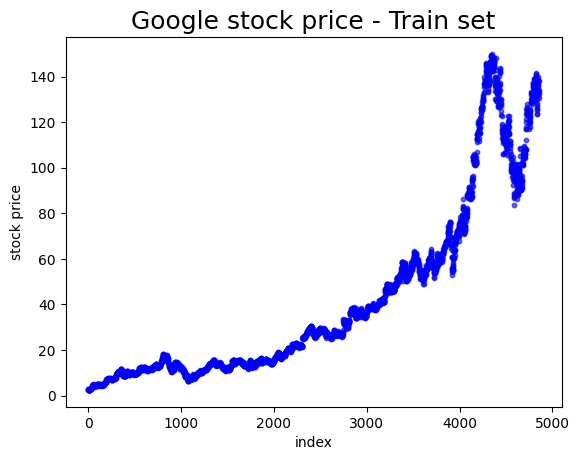

In [245]:
plt.scatter(x_train, y_train,
                  color="blue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.xlabel("index")
plt.ylabel("stock price")
plt.title("Google stock price - Train set", fontsize=18)
plt.show()

# Simple Linear Regression (단순선형회귀)

In [246]:
from sklearn.linear_model import LinearRegression

In [247]:
SLR = LinearRegression()

SLR.fit(x_train,y_train)
SLR

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


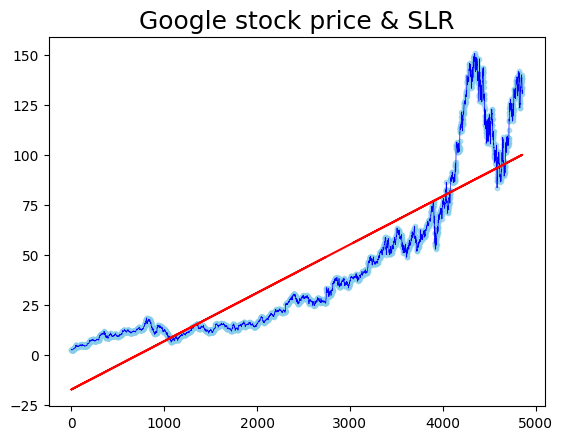

In [248]:
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5)
plt.plot(x_train,SLR.predict(x_train),
             color="red")
plt.title("Google stock price & SLR", fontsize=18)
plt.show()

# Stochastic Gradient Descent (확률적 경사하강법)

In [249]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

In [250]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_scaled = scaler.transform(x)

In [251]:
SGD = SGDRegressor(eta0=0.001)
SGD.fit(x_train_scaled, y_train)

c:\Users\SAMSUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


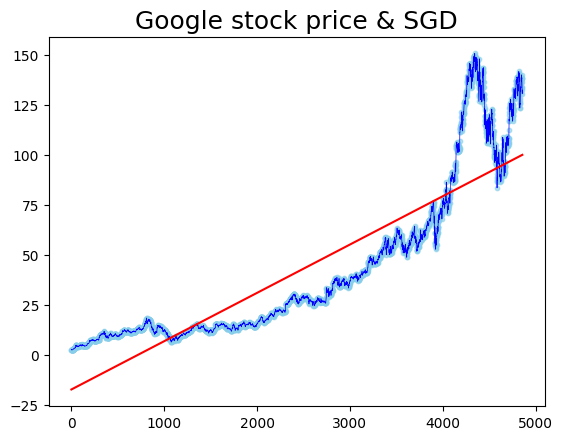

In [252]:
plt.scatter(x, y,
                  color="skyblue",
                  marker="o",
                  alpha=0.6,
                  s=10)
plt.plot(x, y,
                  color="blue",
                  linewidth=0.5)
plt.plot(x,SGD.predict(x_scaled),
             color="red")
plt.title("Google stock price & SGD", fontsize=18)
plt.show()